# Predicting Municipal Solid Waste (MSW) Generation in Africa

This notebook builds a regression model that predicts total municipal solid waste (MSW) generated per year for African countries, using population, GDP, and waste-composition features.

**Overall workflow:**
1. Load and filter the dataset to African countries
2. Select features and target, clean data types
3. Explore the data visually
4. Build a preprocessing pipeline (scaling + encoding)
5. Train a Stochastic Gradient Descent (SGD) model epoch-by-epoch and track its loss curve
6. Compare SGD against Linear Regression, Decision Tree, and Random Forest
7. Save the best-performing model and visualize its predictions

## 1. Imports

We bring in libraries for data handling (`pandas`, `numpy`), plotting (`matplotlib`, `seaborn`), model persistence (`joblib`), and the scikit-learn tools needed to preprocess data, split it, and train several regression models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

## 2. Load data and filter for African countries

We read the full country-level CSV, then keep only rows belonging to Africa:
- Sub-Saharan Africa, identified by the World Bank region code `'SSF'`
- North Africa, identified by explicitly listing the ISO3 country codes for Algeria, Egypt, Libya, Morocco, and Tunisia (since these countries are usually grouped under the Middle East & North Africa region code rather than `'SSF'`)

The `.copy()` avoids `SettingWithCopyWarning` issues later when we modify this subset.

In [2]:
df = pd.read_csv("country_level_data_0.csv")

# Filter for African countries (Sub-Saharan Africa 'SSF' + North African ISOs)
north_africa_iso = ['DZA', 'EGY', 'LBY', 'MAR', 'TUN']
df_africa = df[(df['region_id'] == 'SSF') | (df['iso3c'].isin(north_africa_iso))].copy()

## 3. Define features and target, then clean the data

**Features (inputs to the model):**
- `country_name` — categorical, one-hot encoded later
- `population_population_number_of_people` — total population
- `gdp` — gross domestic product
- `composition_food_organic_waste_percent` — % of waste stream that is organic/food waste
- `composition_plastic_percent` — % of waste stream that is plastic

**Target (what we're predicting):** `total_msw_total_msw_generated_tons_year`

We drop rows where the target is missing (a model can't learn from an unlabeled example), then force the numeric feature columns to a proper float type with `pd.to_numeric(..., errors='coerce')`. This safely turns any malformed entries (e.g. stray text or symbols in a numeric column) into `NaN` instead of throwing an error — those `NaN`s will be handled by the imputer in the pipeline later.

In [3]:
# Define Features & Target
features = [
    'country_name',
    'population_population_number_of_people',
    'gdp',
    'composition_food_organic_waste_percent',
    'composition_plastic_percent'
]
target = 'total_msw_total_msw_generated_tons_year'

# Keep rows with non-null target
data = df_africa[features + [target]].dropna(subset=[target]).copy()

# Force numeric columns to float (coerce invalid entries to NaN safely)
num_cols = ['population_population_number_of_people', 'gdp', 'composition_food_organic_waste_percent', 'composition_plastic_percent']
for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

cat_cols = ['country_name']

## 4. Explore the target's distribution

Waste-generation totals tend to be heavily right-skewed (a few countries generate vastly more waste than most others). We apply `np.log1p` (log(1+x), which safely handles zero values) to compress that skew and get a more symmetric, bell-shaped distribution — this is the same log transform we'll later use as the model's actual training target.

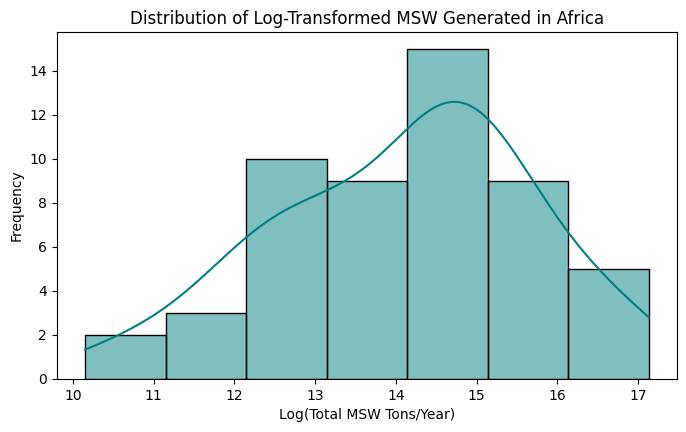

In [4]:
plt.figure(figsize=(8, 4.5))
sns.histplot(np.log1p(data[target]), kde=True, color='teal')
plt.title("Distribution of Log-Transformed MSW Generated in Africa")
plt.xlabel("Log(Total MSW Tons/Year)")
plt.ylabel("Frequency")
plt.savefig("msw_distribution.png", bbox_inches='tight')
plt.show()

## 5. Explore the relationship between population and waste generated

A log-log scatter plot is a natural choice here: both population and waste output can span several orders of magnitude across countries, and plotting on log scales makes power-law-like relationships (e.g. "waste roughly scales with population") appear as a straight line, which is easier to visually assess than on a linear scale.

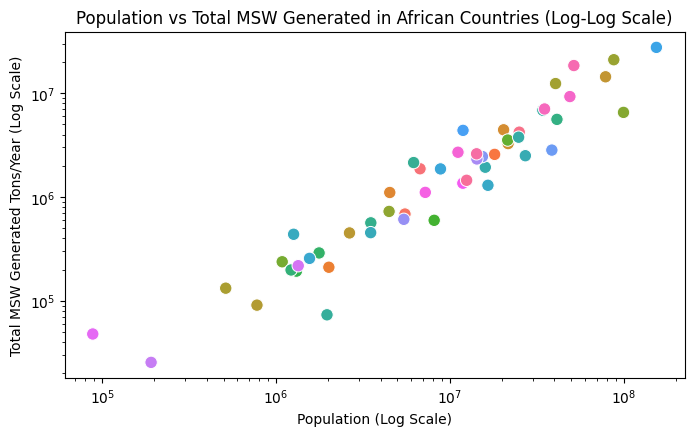

In [5]:
plt.figure(figsize=(8, 4.5))
sns.scatterplot(data=data, x='population_population_number_of_people', y=target, hue='country_name', legend=False, s=80)
plt.xscale('log')
plt.yscale('log')
plt.title("Population vs Total MSW Generated in African Countries (Log-Log Scale)")
plt.xlabel("Population (Log Scale)")
plt.ylabel("Total MSW Generated Tons/Year (Log Scale)")
plt.savefig("population_vs_msw.png", bbox_inches='tight')
plt.show()

## 6. Build the preprocessing pipeline

`X` holds the feature columns; `y` is the **log-transformed** target (`log1p`), which stabilizes variance and makes the regression easier to fit, since the raw target is heavily skewed (as we saw in the histogram).

We define two preprocessing pipelines and combine them with a `ColumnTransformer`:
- **Numeric pipeline**: fill missing values with the **median** (robust to outliers), then scale with `StandardScaler` so all numeric features are on a comparable scale — this matters especially for the SGD-based model, which is sensitive to feature scale.
- **Categorical pipeline**: fill missing values with the **most frequent** category, then apply `OneHotEncoder` to convert `country_name` into binary indicator columns. `handle_unknown='ignore'` prevents errors if the test set contains a country not seen during training.

In [6]:
X = data[features]
y = np.log1p(data[target]) # Log-transform target for regression stability

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

## 7. Split the data and apply preprocessing

We hold out 20% of the data as a test set (`test_size=0.2`) to evaluate the model on unseen countries later. `random_state=42` makes the split reproducible.

`fit_transform` is used on the training set (it *learns* the median/most-frequent values and scaling parameters from training data), while `transform` (no `fit`) is used on the test set — this avoids **data leakage**, since the test set must be treated as if it were new, unseen data.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess training and test data
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

## 8. Train an SGD Regressor epoch-by-epoch

Instead of calling `.fit()` once, we manually loop for 150 `epochs`, calling `partial_fit` each time. This lets us:
- Keep the model's learned weights between iterations (`warm_start=True`)
- Record the training and test loss (Mean Squared Error) **after every single epoch**

This produces the data needed to plot a learning curve and check for underfitting/overfitting.

Key parameters:
- `max_iter=1, tol=None`: forces exactly one pass over the data per `partial_fit` call, so we control the epoch loop ourselves
- `learning_rate='constant', eta0=0.01`: uses a fixed step size for gradient updates rather than one that decays automatically

In [8]:
epochs = 150
sgd_model = SGDRegressor(max_iter=1, tol=None, warm_start=True, random_state=42, learning_rate='constant', eta0=0.01)

train_losses = []
test_losses = []

for epoch in range(epochs):
    sgd_model.partial_fit(X_train_prep, y_train)

    # Calculate Mean Squared Error loss for Train and Test sets
    train_pred = sgd_model.predict(X_train_prep)
    test_pred = sgd_model.predict(X_test_prep)

    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))

## 9. Plot the SGD loss curve

Plotting train vs. test MSE across epochs helps diagnose the model's training behavior:
- Both curves dropping and converging → good fit
- Train loss much lower than test loss → possible overfitting
- Both curves staying high/flat → possible underfitting or learning rate issues

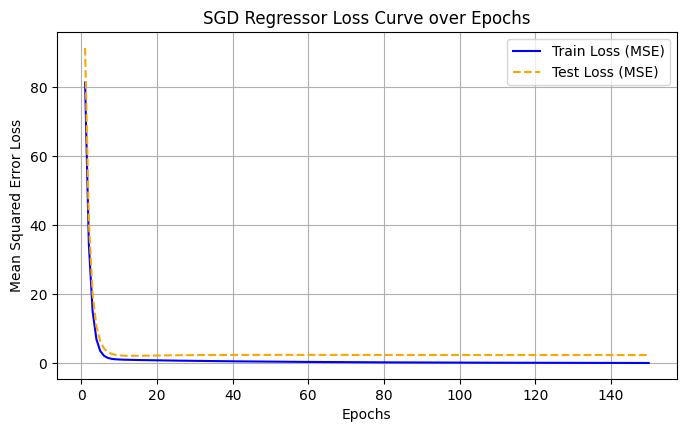

In [9]:
plt.figure(figsize=(8, 4.5))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss (MSE)', color='blue')
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss (MSE)', color='orange', linestyle='--')
plt.title("SGD Regressor Loss Curve over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error Loss")
plt.legend()
plt.grid(True)
plt.savefig("loss_curve.png", bbox_inches='tight')
plt.show()

## 10. Compare against other regression models

We fit three additional, commonly-used regressors on the same preprocessed data for comparison:
- **Linear Regression** — simple baseline, no regularization or tuning
- **Decision Tree** (`max_depth=5`) — captures non-linear relationships, depth limited to reduce overfitting
- **Random Forest** (`n_estimators=100`) — an ensemble of decision trees, usually more robust than a single tree

Each model's test-set MSE is stored in the `results` dictionary alongside the SGD model's final test loss, so they can all be compared on equal footing.

In [10]:
other_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {
    'Stochastic Gradient Descent': (sgd_model, test_losses[-1])
}

for name, model in other_models.items():
    model.fit(X_train_prep, y_train)
    preds = model.predict(X_test_prep)
    mse = mean_squared_error(y_test, preds)
    results[name] = (model, mse)
    print(f"Model: {name:<28} | Test MSE Loss: {mse:.4f}")

Model: Linear Regression            | Test MSE Loss: 1.7220
Model: Decision Tree                | Test MSE Loss: 0.2903
Model: Random Forest                | Test MSE Loss: 0.2541


## 11. Select and save the best model

We pick whichever model has the **lowest test MSE** from the `results` dictionary. Rather than saving the raw model alone, we wrap it together with the `preprocessor` in a single `Pipeline` — this means the saved `.pkl` file can take *raw* input data (with the original column names/types) and produce predictions directly, without needing to remember to manually re-apply preprocessing at prediction time.

In [11]:
best_model_name = min(results, key=lambda k: results[k][1])
best_regressor = results[best_model_name][0]

# Wrap in pipeline to save preprocessor + model together
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', best_regressor)
])

joblib.dump(best_pipeline, "best_model.pkl")
print(f"\n Best Model Saved: '{best_model_name}' with MSE: {results[best_model_name][1]:.4f}")


 Best Model Saved: 'Random Forest' with MSE: 0.2541


## 12. Visualize predicted vs. actual values

As a final sanity check, we plot the best model's predictions against the true (log-transformed) values on the test set, along with a red dashed "ideal fit" line (`y = x`). Points closer to this line indicate more accurate predictions; systematic deviation from the line (e.g. consistently below it at high values) would suggest the model struggles with certain ranges, such as very large or very small countries.

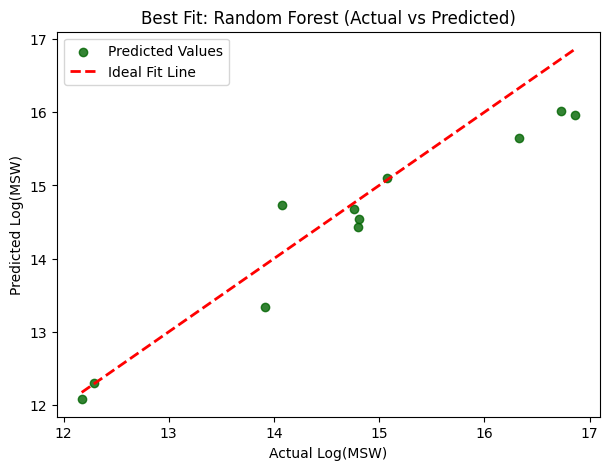

In [12]:
best_preds = best_pipeline.predict(X_test)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, best_preds, color='darkgreen', alpha=0.8, label='Predicted Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit Line')
plt.xlabel("Actual Log(MSW)")
plt.ylabel("Predicted Log(MSW)")
plt.title(f"Best Fit: {best_model_name} (Actual vs Predicted)")
plt.legend()
plt.savefig("best_fit_scatter.png", bbox_inches='tight')
plt.show()